# 1번 불량률 문제 
한 공장에서 생산된 제품에서 최근 추정 불량률은 90% 였다. <br> 오차의 한계가 5% 이하가 되도록하는 최소 표본 사이즈를 구하여라. 

In [1]:
## 완전 기초통계 내용 
## 최근 추정, 기초통계 내용이 많이 나옴, 기본적인 용어 등을 익히고 있어야 함 
## python 으로 풀지 않아도 되는 문제들 

# 모비율에 대한 추정, 신뢰구간의 공식  
* 95% 신뢰구간의 뜻은 모집단 평균이 포함되는 구간이 95% 확률로 생성된다는 의미 
* 오차한계 = Z_0.05 * std/sqrt(n) 


In [2]:
def calculate_sample_size(p, z, d) :
    n = p*(1-p)*(z**2)/(d**2)
    print("최소 샘플사이즈는 {}보다 커야합니다".format(n))
    

In [3]:
calculate_sample_size(0.9, 1.96,0.05)

최소 샘플사이즈는 138.29759999999993보다 커야합니다


따라서 정답은 139이다. 

# 2번 문제 

다음은 1월부터 9월까지의 은의 가격이다

1.  은의 가격 및 이동평균값 3이 설정된 시계열 그래프를 그리세요. 
2.  1월 대비 9월의 은의 가격은 몇 % 올랐는가? (소수점 두번째 자리에서 반올림)

In [4]:
# 라이브러리 불러오기 
import pandas as pd 
import numpy as np

data = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/26_problem4.csv")
data

,1M,2M,3M,4M,5M,6M,7M,8M,9M
0,12.14,42.6,34.4,35.29,30.96,57.12,37.84,42.49,31.38


In [5]:
ma_data = data.transpose() 
ma_data.columns = ["month_price"]
ma_data

,month_price
1M,12.14
2M,42.60
3M,34.40
4M,35.29
5M,30.96
6M,57.12
7M,37.84
8M,42.49
9M,31.38


In [6]:
ma_data["ma_3"] = 0 
ma_data.loc["3M","ma_3"] = ma_data["month_price"][0:3].mean()
ma_data.loc["4M","ma_3"] = ma_data["month_price"][1:4].mean()
ma_data.loc["5M","ma_3"] = ma_data["month_price"][2:5].mean()
ma_data.loc["6M","ma_3"] = ma_data["month_price"][3:6].mean()
ma_data.loc["7M","ma_3"] = ma_data["month_price"][4:7].mean()
ma_data.loc["8M","ma_3"] = ma_data["month_price"][5:8].mean()
ma_data.loc["9M","ma_3"] = ma_data["month_price"][6:9].mean()

ma_data

,month_price,ma_3
1M,12.14,0.000000
2M,42.60,0.000000
3M,34.40,29.713333
4M,35.29,37.430000
5M,30.96,33.550000
6M,57.12,41.123333
7M,37.84,41.973333
8M,42.49,45.816667
9M,31.38,37.236667


In [7]:
## 한 7행 정도라면 for문을 작성하는 것보다는 그냥 복사 붙여넣기로 하는게 편한듯 
## 시험장에서는 단순한게 최고!! 

for i in range(3,10): 
    ma_data.loc["{}M".format(i),"ma_3"] = ma_data["month_price"][i-3:i].mean()
    
ma_data

,month_price,ma_3
1M,12.14,0.000000
2M,42.60,0.000000
3M,34.40,29.713333
4M,35.29,37.430000
5M,30.96,33.550000
6M,57.12,41.123333
7M,37.84,41.973333
8M,42.49,45.816667
9M,31.38,37.236667


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


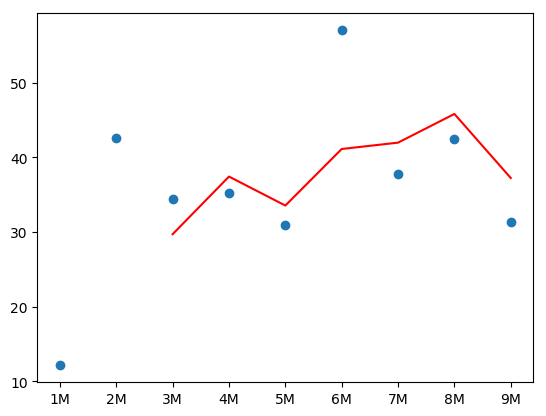

In [8]:
import matplotlib.pyplot as plt 
plt.scatter(x=ma_data.index ,y = ma_data["month_price"])
plt.plot(ma_data.index[2:], ma_data["ma_3"][2:],c='red')

#  1월 대비 9월의 은의 가격은 몇 % 올랐는가? 소수점 두번째 자리에서 반올림

In [9]:
round(ma_data["month_price"][-1]/ma_data["month_price"][0]*100,1)

258.5

# 3번 문제 

1. 아래 그래프는 A,B,C 자치구별 H 의원에 대한 찬성, 반대 투표 결과이다.자치구별 지지율이 같은지에 대해서 검정하라. 



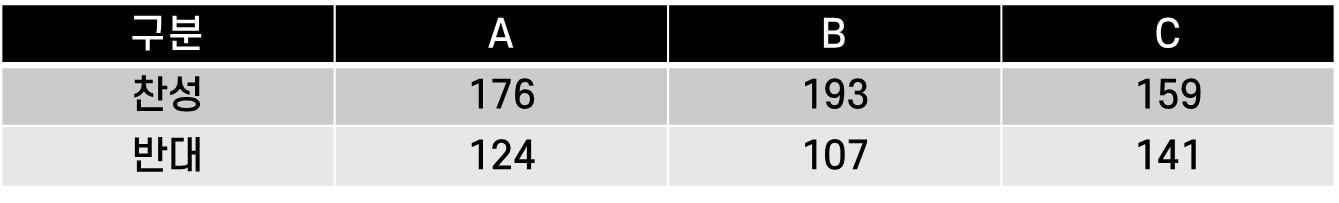

In [10]:
import pandas as pd 
import numpy as np 
data = pd.DataFrame({"vote" :["찬성","반대"],
                    "A" : [176,124],
                    "B" : [193,107],
                    "C" : [159,141]})
data

,vote,A,B,C
0,찬성,176,193,159
1,반대,124,107,141


In [11]:
data.set_index("vote",inplace=True) ## 교차표를 만들어 주기 위해 인덱스 설정 
data

,A,B,C
vote,,,
찬성,176,193,159
반대,124,107,141


In [12]:
# 카이제곱 검정을 통한 독립성 검정 수행
from scipy.stats import chi2_contingency

chi, p, df, expect = chi2_contingency(data) 

print('Statistic:', chi)
print('p-value:', p)
print('df:', df)
print('expect: \n', expect)

print("\n p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각")
print("\n 자치구와 지지율은 독립이 아니라고 할 수 있다. 즉, 자치구별 H의원에 대한 지지율은 다르다.")

Statistic: 7.945381231671554
p-value: 0.01882272023214683
df: 2
expect: 
 [[176. 176. 176.]
 [124. 124. 124.]]

 p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각

 자치구와 지지율은 독립이 아니라고 할 수 있다. 즉, 자치구별 H의원에 대한 지지율은 다르다.


# 4번문제

## A학교 남녀 학생들의 평균 혈압 차이가 있는지 여부에 대한 검정 문제 

* 단, 남학생과 여학생의 혈압 데이터는 정규분포를 따르며 등분산임을 가정한다


> 1) 남녀 학생들의 평균 혈압 차이가 있는지에 대해 가설을 설정하라 

> 2) 검정통계량을 구하고 판단해라 

> 3) 평균 혈압차의 신뢰구간을 구했을 때, 판단한 결과가 2) 의 결과를 지지하는지 설명해라 

## 1) 남녀 학생들의 평균 혈압 차이가 있는지에 대해 가설을 설정하라

### 귀무가설 : A학교에서 성별에 따른 평균 혈압 차이는 없다. 
### 대립가설 : A학교에서 성별에 따른 평균 혈압 차이는 있다. 

In [13]:
import pandas as pd 
data = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/26_problem6.csv")
data.head()

,gender,pressure
0,male,106.8
1,male,100.8
2,male,84.5
3,male,104.2
4,male,107.0


In [14]:
# 성별에 따른 혈압이 등분산성을 만족한다는 조건 하에 독립 t검정 수행 (ttest_ind), default is 'two-sided' 
import scipy.stats as stats

## 데이터 나누기 
male = data.loc[data.gender == 'male', 'pressure']
female = data.loc[data.gender == 'female', 'pressure']

test_result = stats.ttest_ind(male, female, equal_var=True)
test_result

Ttest_indResult(statistic=1.3813481801194591, pvalue=0.18044550626193734)

검정 결과: 귀무가설 기각하지 못한다. \
즉, 성별에 따라 평균 혈압의 차이가 없다고 할 수 있다. 

# 3) 평균 혈압차의 신뢰구간을 구했을 때, 판단한 결과가 2) 의 결과를 지지하는지 설명해라

In [15]:
import numpy as np
from scipy.stats import t

# 1. 통합 표준편차(Pooled Standard Deviation) 함수 수정
def sp(data1, data2): 
    # len(data)를 len(data1)로 수정
    df = len(data1) + len(data2) - 2
    s1 = (len(data1) - 1) * (data1.std()**2)
    s2 = (len(data2) - 1) * (data2.std()**2)
    pooled_std = np.sqrt((s1 + s2) / df)
    return pooled_std 

alpha = 0.95 
dof = len(male) + len(female) - 2
diff_mean = male.mean() - female.mean()

# 2. 표준오차 공식 수정 (np.sqrt 추가)
s = sp(male, female) * np.sqrt(1/len(male) + 1/len(female))

# 3. 신뢰구간 계산
CI = t.interval(alpha, dof, loc=diff_mean, scale=s) 
print(f"95% 신뢰구간: {CI}")

95% 신뢰구간: (-2.635362714413927, 13.228418269969492)


# 신뢰구간 : [-2.635 , 13.228]  
* 소숫점 4째 자리 반올림 


[답안]결과: 95% 신뢰구간을 계산한 결과 [하한값, 상한값]이며, 이 구간 안에 0이 포함됩니다.

지지 여부: 구간 내에 0이 포함된다는 것은 두 집단의 평균 차이가 0일 가능성이 충분하다는 것을 의미합니다.

결론: 이는 앞서 2)번 문제에서 수행한 독립표본 t-검정 결과인 $p \text{-value} = 0.1804$ (유의수준 0.05보다 커서 귀무가설 채택)와 논리적으로 일치하며, 따라서 신뢰구간 분석 결과는 앞선 검정 결과를 강력하게 지지합니다.

# 5번문제 
eight(키), weight(몸무게), waist(허리둘레) 컬럼을 가진 26_problem7.csv파일을 가지고 다음을 분석하라
A시의 20대 남성 411명을 임의로 추출하여 키, 몸무게, 허리둘레를 조사하여 기록한 데이터이다.
이 데이터를 이용하여 20대 남성의 키와 허리둘레가 체중에 영향을 미치는지 알아보고자 한다.

5.1 아래 조건에 맞추어 회귀계수(반올림하여 소수점 두자리)를 구하시오.

조건 1: 독립변수($X$)는 height와 waistline으로, 종속변수($y$)는 weight로 설정하시오.

조건 2: scikit-learn의 ARDRegression 알고리즘을 사용하시오.

조건 3: 모델의 최대 반복 횟수(n_iter)는 1,000으로 설정하고, 절편(fit_intercept)을 미포함하여 학습시키시오.


5.2 위에서 만든 모델을 바탕으로 키 180cm, 허리둘레 85cm인 남성의 몸무게를 추정하라


In [16]:
import pandas as pd
from sklearn.linear_model import ARDRegression

# 1. 데이터 로드
data = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/26_problem7.csv")
data

,height,weight,waistline
0,174.396,72.102,79.3787
1,179.656,81.255,80.6649
2,175.079,76.207,80.3166
3,180.804,81.354,80.8794
4,177.448,78.768,80.3499
...,...,...,...
406,174.207,73.736,80.1779
407,174.702,74.529,80.1306
408,176.858,76.083,80.4527
409,175.566,76.459,80.2019


In [17]:
# 2. 변수 설정 (조건 1)
X = data[['height', 'waistline']]
y = data['weight']

# 3. 모델 생성 및 학습 (조건 2, 3)
model = ARDRegression(n_iter=1000, fit_intercept=False)
model.fit(X, y)

# 4. 회귀계수 출력 (반올림 소수점 두자리)
print(f"회귀계수(height): {round(model.coef_[0], 2)}")
print(f"회귀계수(waistline): {round(model.coef_[1], 2)}")

회귀계수(height): 1.16
회귀계수(waistline): -1.59


In [18]:
# 수정 전
# clf.predict([[180, 85]]) 

# 수정 후
pred = model.predict([[180, 85]])
print(f"추정 몸무게: {pred[0]:.5f}")

추정 몸무게: 72.70257


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but ARDRegression was fitted with feature names
  "X does not have valid feature names, but"


In [19]:
## 추정 몸무게  정답 : 72.70257